# Exercise 2

Deadline 18.11.2025

Anna Bütfering

Lea Neumann

Juan Provencio

## Two dimensional data with bottleneck

Use pytorch to implement and train an autoencoder. The autoencoder's constructor should have
four arguments:

**input_size**: the data dimension (so that we can later reuse the autoencoder in task 3)

**bottleneck_size**: the code dimension (also for reuse in task 3 in the present task the code dimension is always 1)

**hidden_size**: the dimension of the hidden layers (should be larger than the data dimension!)

**layers**: the number of hidden layers

In [21]:
# Torch
import torch 
from torch import nn, optim
# Sklearn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
# Etc.
import matplotlib.pyplot as plt
from tqdm import tqdm
## Plot options
from cycler import cycler
from matplotlib import rcParams
rcParams['axes.grid'] = True
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.5
rcParams['axes.labelsize'] = 20
rcParams['axes.prop_cycle'] = cycler('color', ['#C61A27', '#3891A6', \
                                               '#F79D65', '#FDE74C', \
                                                '#9BC53D', '#5BC0EB'])
colors = rcParams['axes.prop_cycle'].by_key()['color']
rcParams['axes.titlesize'] = 22
rcParams['figure.figsize'] = (12, 7)
rcParams['figure.titlesize'] = 26
rcParams['font.size'] = 16
rcParams['image.cmap'] = 'magma'
rcParams['lines.markeredgewidth'] = 2
rcParams['lines.markerfacecolor'] = 'white'
rcParams['markers.fillstyle'] = 'none'

In [90]:
# Dataset from two moons:
X, y = make_moons(n_samples=125000, noise=0.1, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
#y = torch.tensor(y, dtype=torch.long)

# Split into train and test sets:
X_test, X_train = train_test_split(X, test_size=0.2, random_state=42)

In [91]:
class Autoencoder(nn.Module):
    def __init__(self, input_size, bottleneck_size, hidden_size, layers):
        # Initialize AE with required parameters
        self.input_size = input_size
        self.bottleneck_size = bottleneck_size
        self.hidden_size = hidden_size
        self.layers = layers
        # Save hyperparameters
        self.lr = 0.001
        # Save results
        self.train_losses = []
        self.test_losses = []
        self.outputs = []

        # Structure: [ENCODER -> {BOTTLENECK] -> DECODER}

        # First call super constructor
        super(Autoencoder, self).__init__()

        # Encoder
        ## Initial layer input -> hidden
        self.encoder = nn.ModuleList()
        self.encoder.append(nn.Linear(input_size, hidden_size))
        self.encoder.append(nn.ReLU())
        ## Hidden layers hidden -> hidden
        for _ in range(layers - 1):
            self.encoder.append(nn.Linear(hidden_size, hidden_size))
            self.encoder.append(nn.ReLU())
        ## Final layer hidden -> bottleneck
        self.encoder.append(nn.Linear(hidden_size, bottleneck_size))

        # Decoder
        ## Initial layer bottleneck -> hidden
        self.decoder = nn.ModuleList()
        self.decoder.append(nn.Linear(bottleneck_size, hidden_size))
        self.decoder.append(nn.ReLU())
        ## Hidden layers hidden -> hidden
        for _ in range(layers - 1):
            self.decoder.append(nn.Linear(hidden_size, hidden_size))
            self.decoder.append(nn.ReLU())
        ## Final layer hidden -> output
        self.decoder.append(nn.Linear(hidden_size, input_size))


    def forward(self, x):
        # Forward pass
        for layer in self.encoder:
            x = layer(x)
        for layer in self.decoder:
            x = layer(x)
        decoded = x
        return decoded

    def train_autoencoder(self, X_train, training_set_size, mini_batch_size, n_epochs, learning_rate):
        # Loss function
        loss_function = nn.MSELoss()
        # Optimizer
        optimizer = optim.Adam(self.parameters(), lr = learning_rate)
        # Use Data loader for mini-batches, use taining_set_size to select subset of data
        loader = torch.utils.data.DataLoader(X_train[:training_set_size], batch_size=mini_batch_size, shuffle=True)

        for epoch in tqdm(range(n_epochs)):
            for X_batch in loader:
                #print(X_batch)
                # Make forward pass
                decoded = self.forward(X_batch)
                # Compute loss
                loss = loss_function(decoded, X_batch)
                # Compute zero-grad
                optimizer.zero_grad()
                # Backprop
                loss.backward()
                # Step
                optimizer.step()
                # Save losses
                self.train_losses.append(loss.item())
            # Save outputs for later
            self.outputs.append((epoch, X_batch, decoded))

### 1. Investigate systematically different hyperparameters:

Starting from `(training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers) = (1000, 32, 10, 0.001, 4, 2)`, we want to test the influence of the different parameters. We'll compute the Mean Squared Error (MSE) to determine the performance of the different parameter configurations. Since a 6 dimensional phase space is very impractical to explore and perform a grid search for the optimal solution, we'll explore every axis individually and from there converge onto a good solution.

In [93]:
# 1 Investigate the influence of training set size given fixed other hyperparameters
hyperparameters_tss = [(1000, 32, 10, 0.001, 4, 2), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                   (10000, 32, 10, 0.001, 4, 2),
                   (50000, 32, 10, 0.001, 4, 2), 
                   (100000, 32, 10, 0.001, 4, 2)]

results_tss = []
for params in hyperparameters_tss:
    print(f"Training with training set size: {params[0]}")
    # Create model
    model_tss = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_tss.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save results
    results_tss.append((params, model_tss.train_losses, model_tss.outputs[-1]))

Training with training set size: 1000


100%|██████████| 10/10 [00:00<00:00, 26.44it/s]


Training with training set size: 10000


100%|██████████| 10/10 [00:03<00:00,  2.84it/s]


Training with training set size: 50000


100%|██████████| 10/10 [00:08<00:00,  1.15it/s]


Training with training set size: 100000


100%|██████████| 10/10 [00:08<00:00,  1.15it/s]


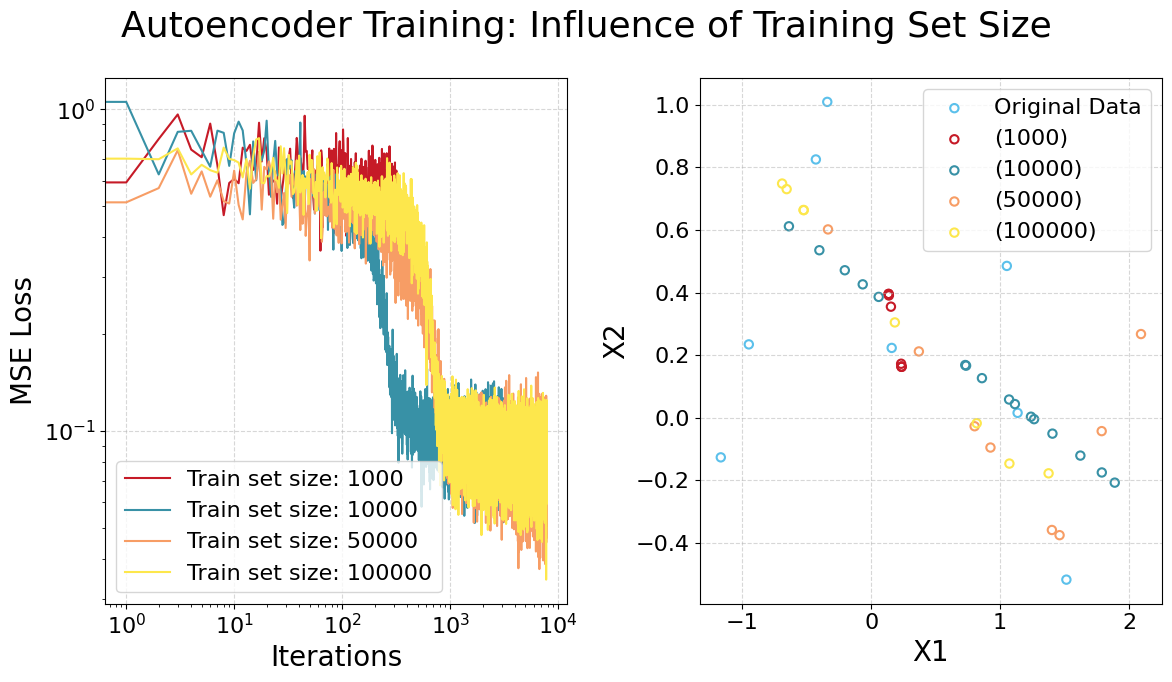

In [96]:
# Plot MSE loss for different training set sizes
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Training Set Size", fontsize=26)
# Plot training losses
for res in results_tss:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Train set size: {params[0]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
#axes[0].set_title("MSE Loss vs Iterations for different Training Set Sizes")
axes[0].legend()
axes[0].loglog()
# Plot final reconstruction

# Get final output
final_epoch, X_batch, decoded = model_tss.outputs[-1]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = colors[5])
for i in range(len(results_tss)):
    final_epoch, X_batch, decoded = results_tss[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"({results_tss[i][0][0]})", 
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
#axes[1].set_title("Final Reconstruction for different Training Set Sizes")
axes[1].legend()
plt.tight_layout()
plt.show()

Simply increasing the test size does obviously no good if the underlying network architecture is poor.

In [97]:
# 1 Investigate the influence of number of epochs given fixed other hyperparameters
hyperparameters_n_epochs = [(2000, 32, 10, 0.001, 4, 2), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                            (2000, 32, 100, 0.001, 4, 2),
                            (2000, 32, 1000, 0.001, 4, 2),
                            (2000, 32, 5000, 0.001, 4, 2)]

results_tss = []
for params in hyperparameters_n_epochs:
    print(f"Training with training set size: {params[0]}, epochs: {params[2]}")
    # Create model
    model_n_epochs = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_n_epochs.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save results
    results_tss.append((params, model_n_epochs.train_losses, model_n_epochs.outputs[-1]))

Training with training set size: 2000, epochs: 10


100%|██████████| 10/10 [00:00<00:00, 10.12it/s]


Training with training set size: 2000, epochs: 100


100%|██████████| 100/100 [00:08<00:00, 12.21it/s]


Training with training set size: 2000, epochs: 1000


100%|██████████| 1000/1000 [01:20<00:00, 12.44it/s]


Training with training set size: 2000, epochs: 5000


100%|██████████| 5000/5000 [06:02<00:00, 13.80it/s]


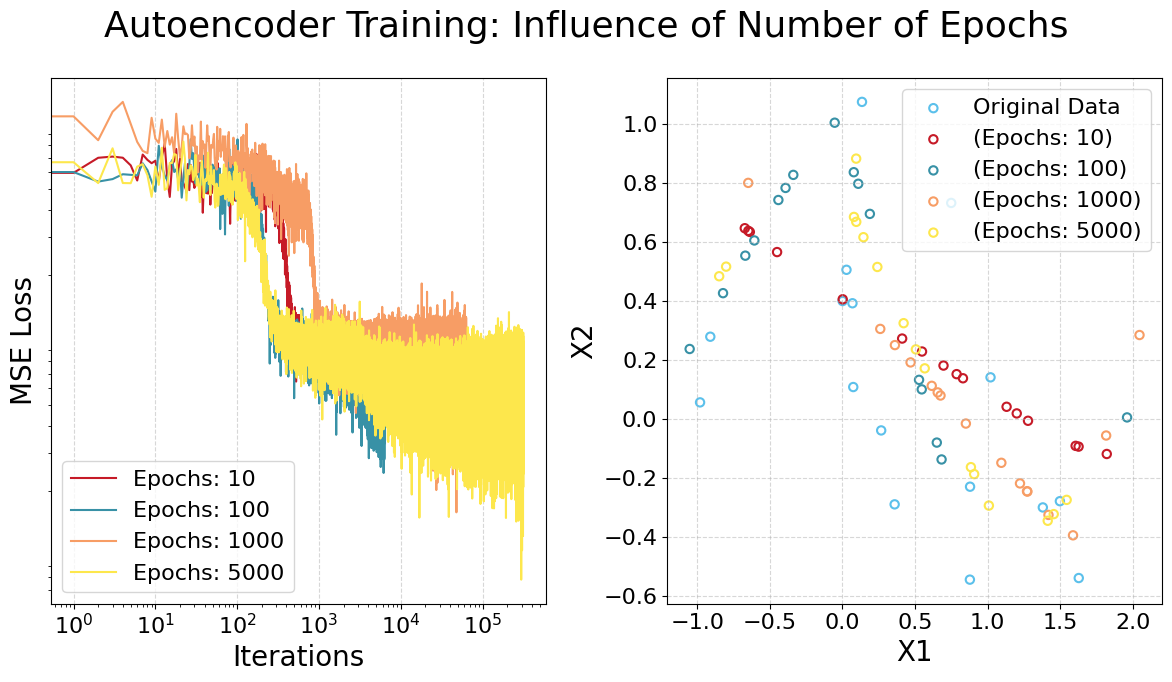

In [98]:
# Plot MSE loss for different number of epochs
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Number of Epochs", fontsize=26)
# Plot training losses
for res in results_tss:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Epochs: {params[2]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
axes[0].loglog('log')
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_tss[-1][2]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = colors[5])
for i in range(len(results_tss)):
    final_epoch, X_batch, decoded = results_tss[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Epochs: {results_tss[i][0][2]})", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].legend()
plt.tight_layout()
plt.show()

Increasing the training iterations by brute force provides mixed and inconsistent results. In the left diagramm, one can seet the MSE loss shows a reduction between 100 and 1000 training iterations and the reconstructed data appears to be in the same order of magnitude as the data, in contrast to the sample where we simply increased the number of training points. Even the best results show a very linear trend and fail to capture the profile of the two moon samples. In some cases, the models trained for 1000 or 5000 epochs approximate the curved behavior with extra diagonal lines. However, our hypothesis is that this will not improve much until we expand the size of our network, as it currently only has 2 layers of dimension 4. Let's first test whether this can be improved by increasing the number of samples the model trains simultaneously from mini_batch_size = 32 -> 256.

In [99]:
# 1 Investigate the influence of mini-batch-size given fixed other hyperparameters
hyperparameters_mbs = [(2000, 32, 1000, 0.001, 4, 2), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                        (2000, 64, 1000, 0.001, 4, 2),
                        (2000, 128, 1000, 0.001, 4, 2),
                        (2000, 256, 1000, 0.001, 4, 2)]

results_mbs = []
for params in hyperparameters_mbs:
    print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}")
    # Create model
    model_mbs = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_mbs.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_mbs.append((params, model_mbs.train_losses, model_mbs.outputs[-1]))

Training with training set size: 2000, n_epochs: 1000, mini batch size: 32


100%|██████████| 1000/1000 [01:12<00:00, 13.79it/s]


Training with training set size: 2000, n_epochs: 1000, mini batch size: 64


100%|██████████| 1000/1000 [00:39<00:00, 25.43it/s]


Training with training set size: 2000, n_epochs: 1000, mini batch size: 128


100%|██████████| 1000/1000 [00:24<00:00, 41.36it/s]


Training with training set size: 2000, n_epochs: 1000, mini batch size: 256


100%|██████████| 1000/1000 [00:16<00:00, 62.09it/s]


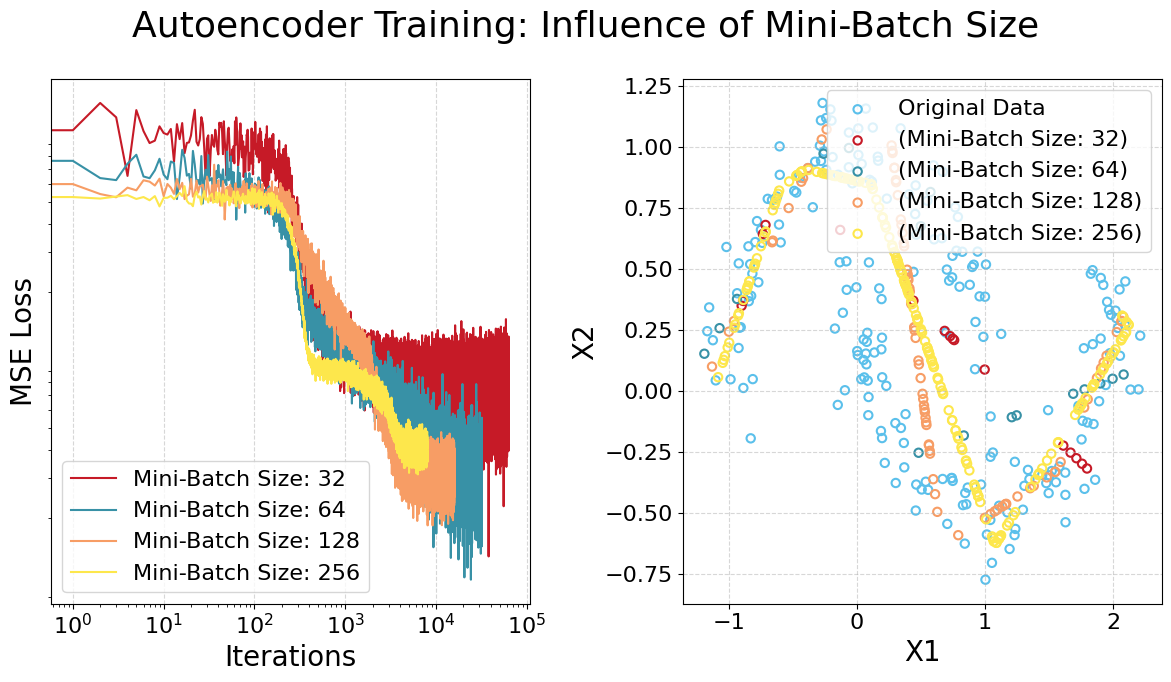

In [100]:
# Plot MSE loss for different mini-batch-sizes
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Mini-Batch Size", fontsize=26)
# Plot training losses
for res in results_mbs:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Mini-Batch Size: {params[1]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
axes[0].loglog('log')
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_mbs[-1][2]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = colors[5])
for i in range(len(results_mbs)):
    final_epoch, X_batch, decoded = results_mbs[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Mini-Batch Size: {results_mbs[i][0][1]})", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].legend()
plt.tight_layout()
plt.show()

As expected, increasing the test-points in every training iteration by using larger mini-batches provides inconsistent or at best marginally better results. Next we will test different network sizes. Since the data is relatively simple, increasing the number of layers beyond a certain extent will likely not provide significant results. Instead, it could cause issues due to vanishing gradients

In [101]:
# 1 Investigate the influence of network-sizes given fixed other hyperparameters
hyperparameters_lyrs = [(2000, 128, 2000, 0.001, 4, 2), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                        (2000, 128, 2000, 0.001, 4, 3),
                        (2000, 128, 2000, 0.001, 4, 4),
                        (2000, 128, 2000, 0.001, 4, 8)]

results_lyrs = []
for params in hyperparameters_lyrs:
    print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}, layers: {params[5]}")
    # Create model
    model_lyrs = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_lyrs.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_lyrs.append((params, model_lyrs.train_losses, model_lyrs.outputs[-1]))

Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, layers: 2


100%|██████████| 2000/2000 [00:48<00:00, 40.93it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, layers: 3


100%|██████████| 2000/2000 [01:03<00:00, 31.51it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, layers: 4


100%|██████████| 2000/2000 [01:18<00:00, 25.43it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, layers: 8


100%|██████████| 2000/2000 [02:07<00:00, 15.63it/s]


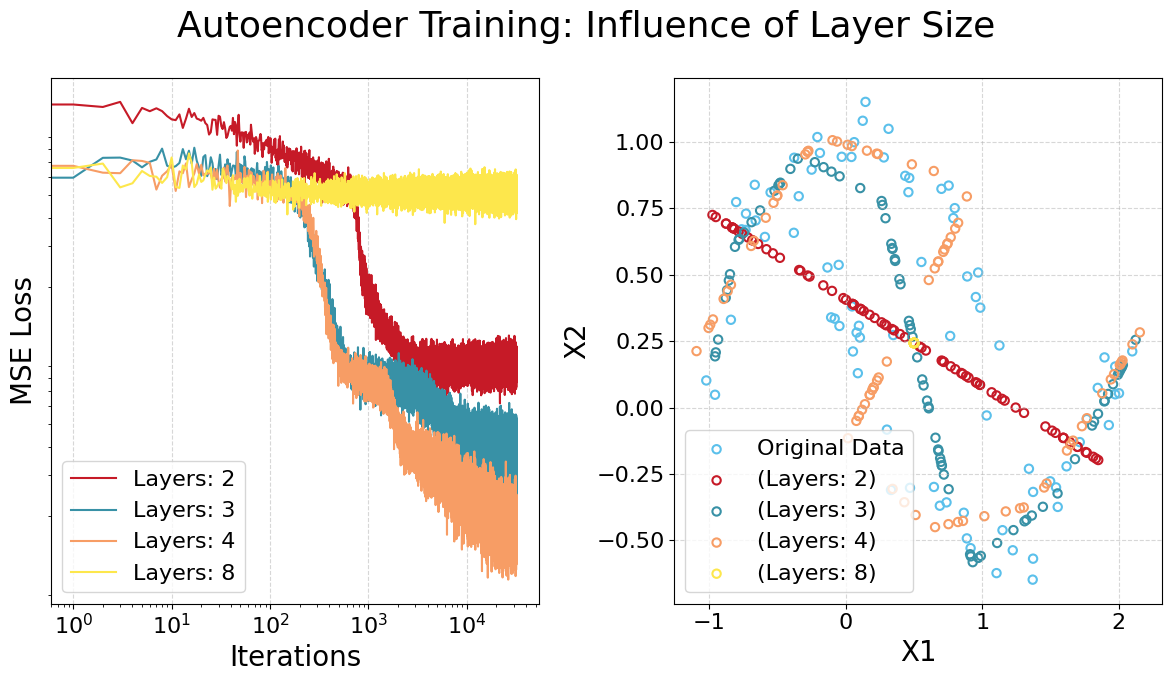

In [102]:
# Plot MSE loss for different layer-sizes
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Layer Size", fontsize=26)
# Plot training losses
for res in results_lyrs:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Layers: {params[5]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
axes[0].loglog('log')
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_lyrs[-1][2]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = colors[5])
for i in range(len(results_lyrs)):
    final_epoch, X_batch, decoded = results_lyrs[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Layers: {results_lyrs[i][0][5]})", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].legend()
plt.tight_layout()
plt.show()

Indeed, increasing the number of layers doesn't correlate with better performance. However, wider layers are more robust against vanishing layers and learn more features such as the curves of the two moons, the gap between them, etc. Likely this is the defining parameter between a model which kind of understands what it should be doing and one which does what it needs to do.

In [103]:
# 1 Investigate the influence of network-sizes given fixed other hyperparameters
hyperparameters_hsize = [(2000, 128, 2000, 0.001, 4, 4), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                        (2000, 128, 2000, 0.001, 8, 4),
                        (2000, 128, 2000, 0.001, 16, 4),
                        (2000, 128, 2000, 0.001, 32, 4)]

results_hsize = []
for params in hyperparameters_hsize:
    print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}, hidden size: {params[4]}, layers: {params[5]}")
    # Create model
    model_hsize = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_hsize.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_hsize.append((params, model_hsize.train_losses, model_hsize.outputs[-1]))

Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 4, layers: 4


100%|██████████| 2000/2000 [01:20<00:00, 24.92it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 8, layers: 4


100%|██████████| 2000/2000 [01:23<00:00, 23.97it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 2000/2000 [01:24<00:00, 23.72it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 32, layers: 4


100%|██████████| 2000/2000 [01:53<00:00, 17.55it/s]


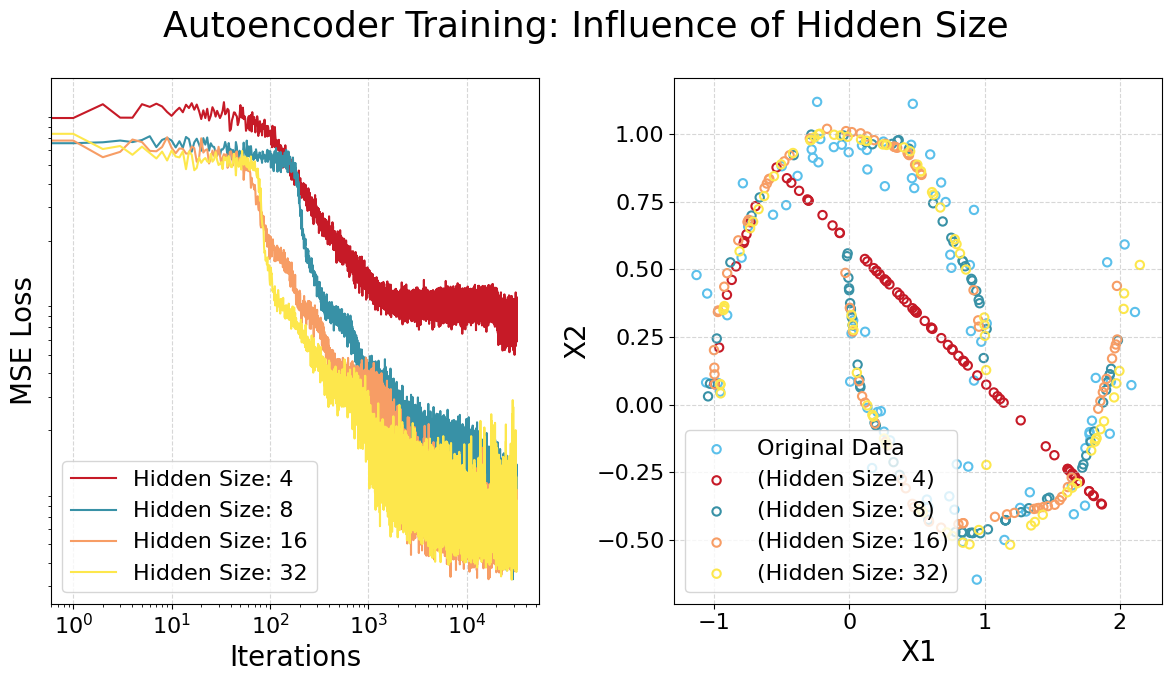

In [104]:
# Plot MSE loss for different hidden-sizes
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Hidden Size", fontsize=26)
# Plot training losses
for res in results_hsize:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Hidden Size: {params[4]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
axes[0].loglog('log')
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_hsize[-1][2]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = colors[5])
for i in range(len(results_hsize)):
    final_epoch, X_batch, decoded = results_hsize[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Hidden Size: {results_hsize[i][0][4]})", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].legend()
plt.tight_layout()
plt.show()

Indeed! Upon visual inspection, the models are learning the nuances of the two moons data, in particularl adapting to the gap between the two moons (hidden size: 32) and following the curves more accurately (hidden size: 8+). Now, we would like to refine the rest of the hyperparameters. For example, the Loss diagram shows that there is still more room to let the model converge, so we should increase the number of iterations it trains for.

In [105]:
# 1 Investigate the influence of network-sizes given fixed other hyperparameters
hyperparameters_refine_n_epochs = [(2000, 128, 2000, 0.001, 16, 4), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                        (2000, 128, 4000, 0.001, 16, 4),
                        (2000, 128, 8000, 0.001, 16, 4),
                        (2000, 128, 10000, 0.001, 16, 4)]

results_refine_n_epochs = []
for params in hyperparameters_refine_n_epochs:
    print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}, hidden size: {params[4]}, layers: {params[5]}")
    # Create model
    model_refine_n_epochs = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_refine_n_epochs.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_refine_n_epochs.append((params, model_refine_n_epochs.train_losses, model_refine_n_epochs.outputs[-1]))

Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 2000/2000 [01:20<00:00, 24.96it/s]


Training with training set size: 2000, n_epochs: 4000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 4000/4000 [02:51<00:00, 23.30it/s]


Training with training set size: 2000, n_epochs: 8000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 8000/8000 [05:46<00:00, 23.08it/s]


Training with training set size: 2000, n_epochs: 10000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 10000/10000 [07:25<00:00, 22.46it/s]


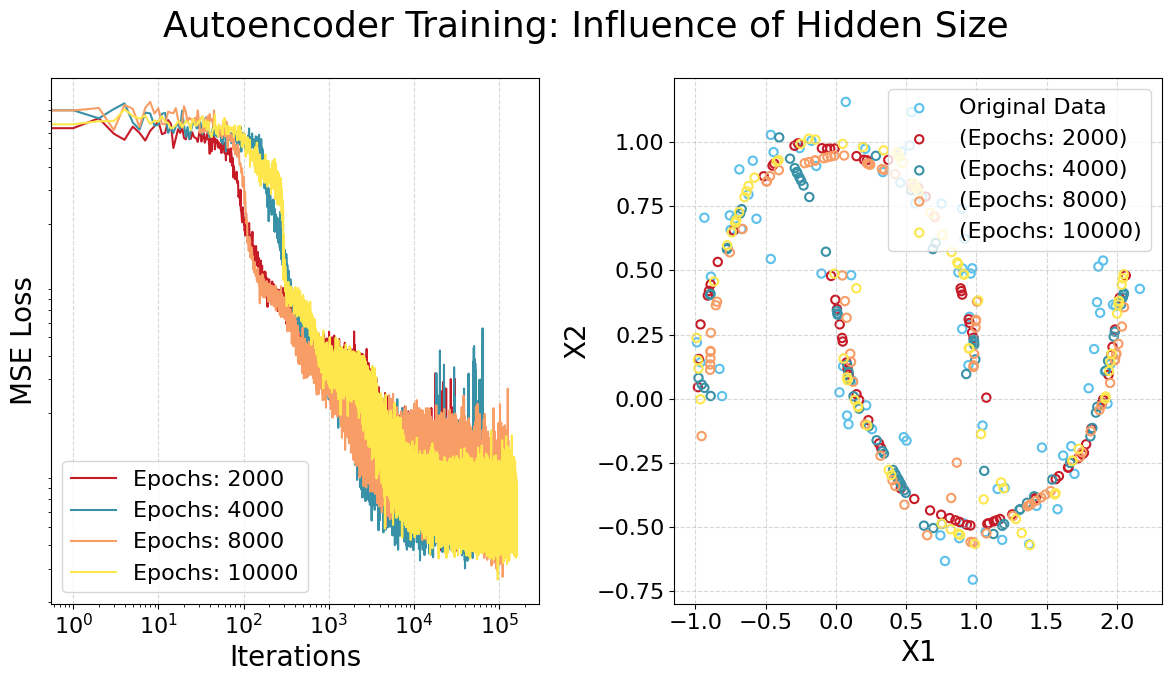

In [108]:
# Plot MSE loss for different hidden-sizes
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Hidden Size", fontsize=26)
# Plot training losses
for res in results_refine_n_epochs:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Epochs: {params[2]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
axes[0].loglog('log')
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_refine_n_epochs[-1][2]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = colors[5])
for i in range(len(results_refine_n_epochs)):
    final_epoch, X_batch, decoded = results_refine_n_epochs[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Epochs: {results_refine_n_epochs[i][0][2]})", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].legend()
plt.tight_layout()
plt.show()

There's no noticeable improvement beyond 2000-4000 training epochs. Next we'll try softer and more aggressive learning rates.

In [109]:
# 1 Investigate the influence of learning rates given fixed other hyperparameters
hyperparameters_refine_lr = [(2000, 128, 4000, 0.1, 16, 4), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                        (2000, 128, 4000, 0.01, 16, 4),
                        (2000, 128, 4000, 0.001, 16, 4),
                        (2000, 128, 4000, 0.0001, 16, 4)]

results_refine_lr = []
for params in hyperparameters_refine_lr:
    print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}, hidden size: {params[4]}, layers: {params[5]}")
    # Create model
    model_refine_lr = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_refine_lr.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_refine_lr.append((params, model_refine_lr.train_losses, model_refine_lr.outputs[-1]))

Training with training set size: 2000, n_epochs: 4000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 4000/4000 [02:43<00:00, 24.46it/s]


Training with training set size: 2000, n_epochs: 4000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 4000/4000 [02:55<00:00, 22.82it/s]


Training with training set size: 2000, n_epochs: 4000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 4000/4000 [02:53<00:00, 23.00it/s]


Training with training set size: 2000, n_epochs: 4000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 4000/4000 [02:56<00:00, 22.63it/s]


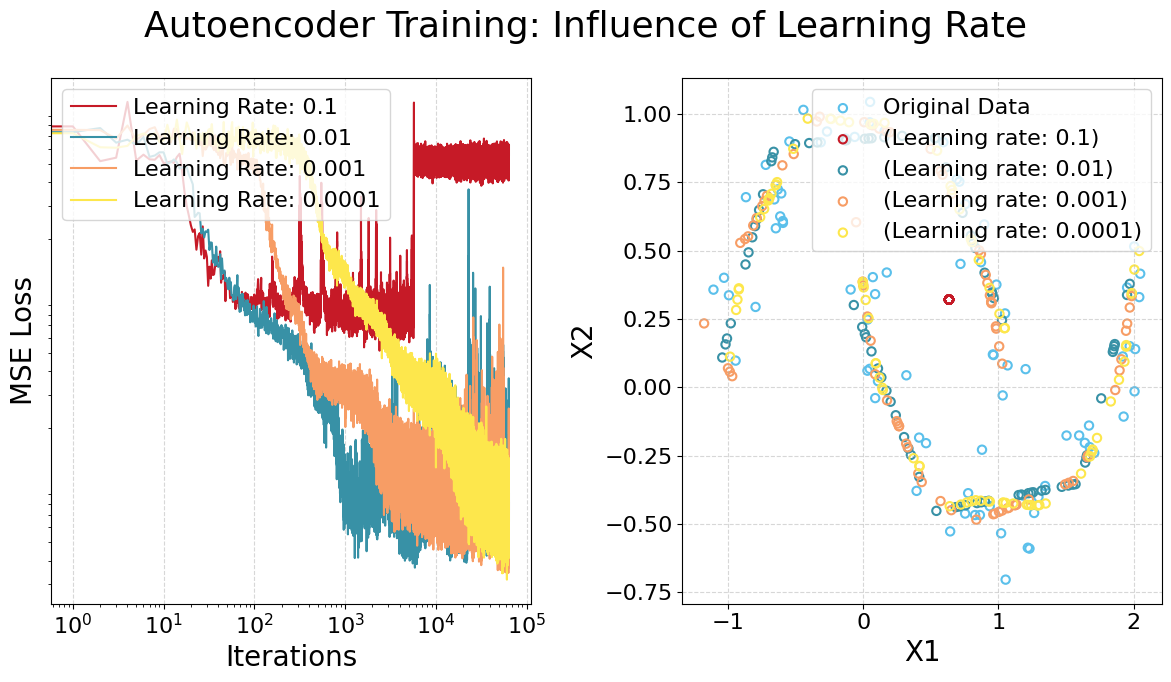

In [111]:
# Plot MSE loss for different learning rates
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Learning Rate", fontsize=26)
# Plot training losses
for res in results_refine_lr:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Learning Rate: {params[3]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
axes[0].loglog('log')
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_refine_lr[-1][2]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = colors[5])
for i in range(len(results_refine_lr)):
    final_epoch, X_batch, decoded = results_refine_lr[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Learning rate: {results_refine_lr[i][0][3]})", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].legend()
plt.tight_layout()
plt.show()

An aggressive learning rate of 0.1 seems to break down at some point, while smaller learning rates do comparatively well and similar to each other, except that a learning rate of 0.0001 simply takes longer to get there compared to 0.01 and 0.001. One could implement a learning schedule, but I think for our purposes with simple data this would be overkill. Instead, we'll stick to a learning rate between 0.01 - 0.001. Now let's try to economize and cut corners where we may have initially overcompensated. For example, we chose 4 hidden layers because it worked best when there were 4 neurons each. Then we settled on 16 neurons each without adjusting the number of layers.

In [129]:
# 1 Investigate the influence of learning rates given fixed other hyperparameters
hyperparameters_refine_hs_lyrs = [(2000, 128, 2000, 0.005, 16, 4),
                                  (2000, 128, 2000, 0.005, 12, 4),
                                  (2000, 128, 2000, 0.005, 16, 3), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                                  (2000, 128, 2000, 0.005, 12, 3),
                                  (2000, 128, 2000, 0.005, 16, 2),
                                  (2000, 128, 2000, 0.005, 12, 2),
                                  #(2000, 128, 2000, 0.005, 8, 2),
                                  #(2000, 128, 2000, 0.005, 6, 2)
                                  ]

results_refine_hs_lyrs = []
for params in hyperparameters_refine_hs_lyrs:
    print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}, hidden size: {params[4]}, layers: {params[5]}")
    # Create model
    model_refine_hs_lyrs = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_refine_hs_lyrs.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_refine_hs_lyrs.append((params, model_refine_hs_lyrs.train_losses, model_refine_hs_lyrs.outputs[-1]))

Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 2000/2000 [01:13<00:00, 27.13it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 12, layers: 4


100%|██████████| 2000/2000 [01:24<00:00, 23.76it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 16, layers: 3


...

100%|██████████| 2000/2000 [01:18<00:00, 25.38it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 16, layers: 2


100%|██████████| 2000/2000 [01:06<00:00, 29.85it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 12, layers: 2


100%|██████████| 2000/2000 [01:07<00:00, 29.53it/s]


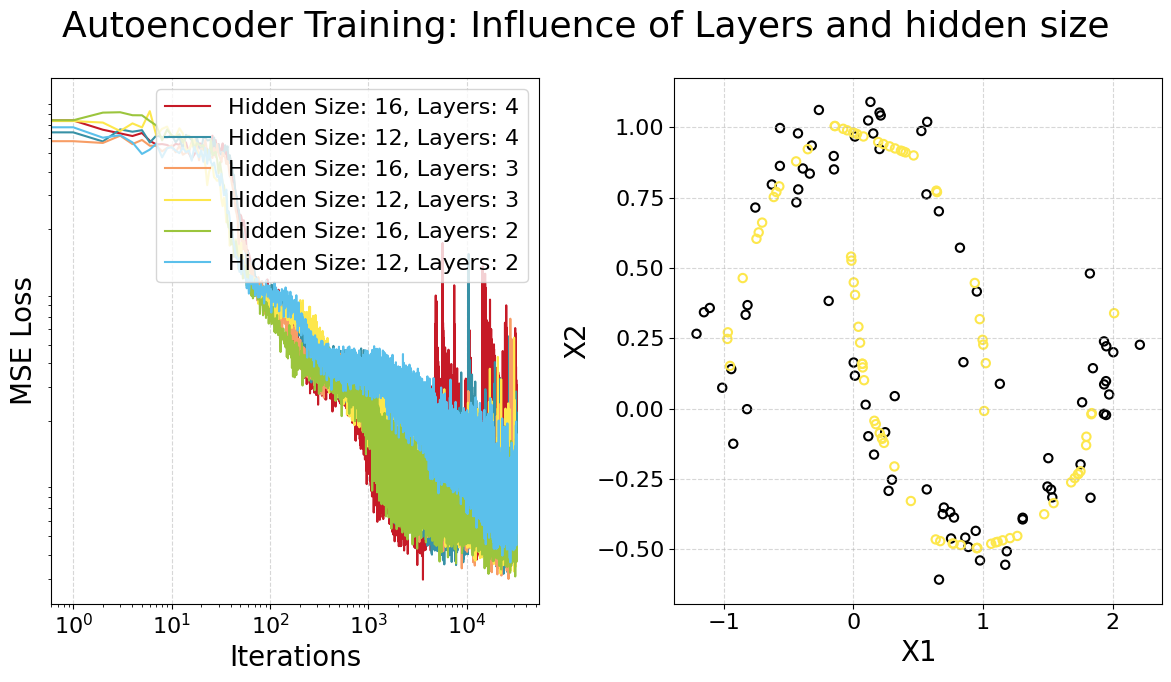

In [139]:
# Plot MSE loss for different learning rates
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Layers and hidden size", fontsize=26)
# Plot training losses
for res in results_refine_hs_lyrs:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Hidden Size: {params[4]}, Layers: {params[5]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
axes[0].loglog('log')
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_refine_hs_lyrs[-1][2]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = "black")
for i in range(len(results_refine_hs_lyrs)):
    if i in [1, 2, 0, 4, 5]:
        continue
    final_epoch, X_batch, decoded = results_refine_hs_lyrs[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Hidden size: {results_refine_hs_lyrs[i][0][4]}, Layers: {results_refine_hs_lyrs[i][0][5]})", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
#axes[1].legend()
plt.tight_layout()
plt.show()

While reducing the number of neurons and layers still yields recognizable results, the lines get smoother and smoother for a wider and slightly deeper architecture. We find the best combination of depth and width to be 3 layers of 16 neurons each.